In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-bright')
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 12
from matplotlib.patches import Patch

from scipy import ndimage
from skimage import io, restoration
from scipy import ndimage, signal

import import_helper
import_helper.add_functions()
import organoid_analysis.geometrical_organoid_analysis as geo
import organoid_analysis.utils as u

#### Analyse annulus TBXT intensities 

- Loop to save intensity data for multiple folders

In [2]:
# pixel size
dx = 1.2268

In [3]:
def loop_to_save_intensity(image_folder, 
                           result_path):
    
    all_images = os.listdir(image_folder)
    n_images = len(all_images)
    
    radii_res = 500
    norm_radii = np.linspace(0, 1, radii_res)[1:] # ignore 0 (a point)
    angle_res = 500
    angles = np.linspace(0, 2*np.pi, angle_res+1)[:-1] # 2pi=0

    df = pd.DataFrame({"radius":norm_radii})

    for i in range(n_images):
        image_name = all_images[i]
        image_path = os.path.join(image_folder, image_name)
        full_image = io.imread(image_path)
        DAPI_channel = full_image[0, :, :]
        TBXT_channel = full_image[1, :, :]

        DAPI_bin = geo.get_binary_image(DAPI_channel, 
                                        intensity_threshold=200,
                                        binary_dilation_iter=5,
                                        binary_closing_iter=20)
        large_contour, small_contour, centre = geo.get_contour_and_centroid(DAPI_bin,
                                                                            smoothing_factor=10**5,
                                                                            annulus=True)
        
        # calculate distances
        distances = np.linalg.norm(large_contour - centre, axis=1)
        min_dist = distances[np.argmin(distances)]
        max_dist = distances[np.argmax(distances)]
        radius = int(min_dist)
        radii = np.linspace(0, radius, radii_res)

        TBXT_intensity = geo.get_intensities_annulus(TBXT_channel,
                                                     large_contour,
                                                     small_contour,
                                                     centre,
                                                     radii,
                                                     angles)
        TBXT_background = geo.simple_background(TBXT_channel, square_size=10)
        DAPI_intensity = geo.get_intensities_annulus(DAPI_channel,
                                                     large_contour,
                                                     small_contour,
                                                     centre,
                                                     radii,
                                                     angles)
        DAPI_background = geo.simple_background(DAPI_channel, square_size=10)

        # normalise and plot
        TBXT_DAPI = geo.mean_ignore_zeros(geo.safe_division(geo.subtract_from_nonzero(TBXT_intensity, TBXT_background),
                                                            geo.subtract_from_nonzero(DAPI_intensity, DAPI_background)))[1:]
        norm_TBXT_DAPI = TBXT_DAPI / TBXT_DAPI.max()
        df[image_name] = norm_TBXT_DAPI
    df.to_csv(result_path)

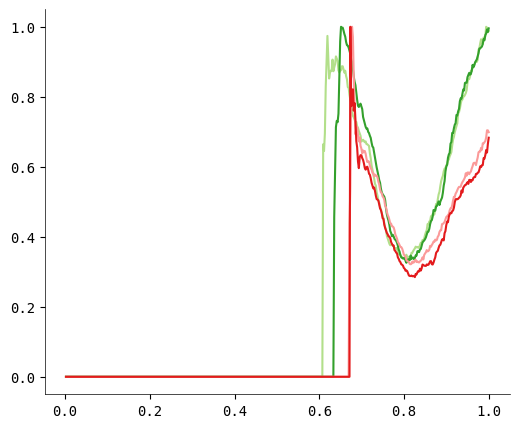

In [4]:
# plot intensities
df = pd.read_csv("../contour_intensities/norm_tbxt_ctrl_annulus1.5_48hr_1000um.csv")
radius = df["radius"]

cmap = plt.get_cmap('Paired')
color_list = [cmap(i) for i in range(15)]

fig, ax = plt.subplots(figsize=(6,5)) 
for i in range(2, len(df.columns.to_numpy())):
    column_name = df.columns[i]
    color= color_list[i] 
    tbxt_norm = df[column_name].to_numpy()
    ax.plot(radius, tbxt_norm, label=column_name, color=color)
# ax.legend(title="Image name", fontsize=8)
# print(df[df.columns[i]].to_numpy())

### Analysis for Annulus TBXT Intensity

In [3]:
folder = "../example_data/annulus/"
all_images = sorted(os.listdir(folder))
image_path = os.path.join(folder, all_images[0])
print(image_path)
full_image = io.imread(image_path) # read image, maximum intensity z project, 5 channels
print(np.shape(full_image))
DAPI_channel = full_image[:, :, 0] # extract DAPI channel
TBXT_channel = full_image[:, :, 1] # extract TBXT channel

../example_data/annulus/example.tif
(1024, 1024, 4)


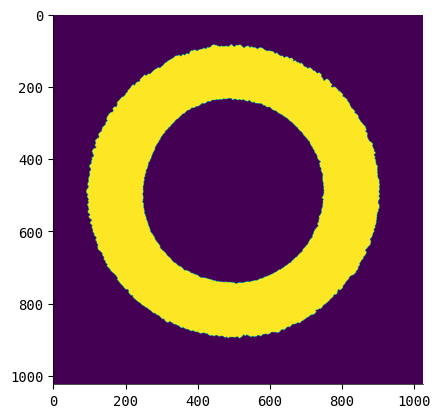

In [4]:
bin_image = geo.get_binary_image(DAPI_channel,
                                 binary_dilation_iter=5,
                                 intensity_threshold=150)
plt.imshow(bin_image)

Text(0.5, 1.0, 'TBXT Intensity')

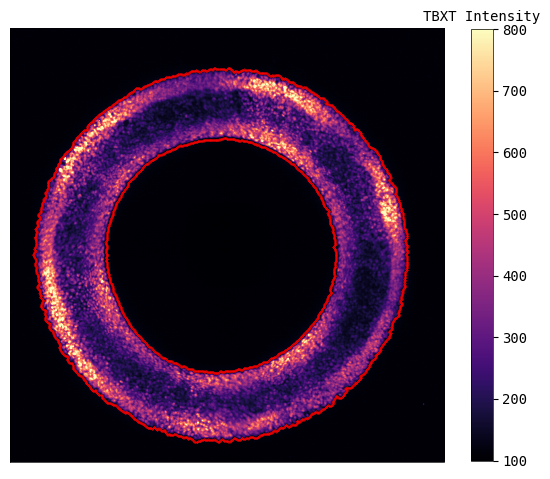

In [5]:
# find large and small contour from binary image
large_contour, small_contour, centre = geo.get_contour_and_centroid(bin_image,
                                                                    smoothing_factor=10**2,
                                                                    annulus=True)
# plotting for visualization
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(TBXT_channel, origin="lower", vmin=100, vmax=800, cmap="magma")
# ax.scatter(centre[1], centre[0], marker='x', color='red')
ax.scatter(small_contour[:,1], small_contour[:,0], color="red", s=0.1)
ax.scatter(large_contour[:,1], large_contour[:,0], color="red", s=0.1)
ax.set_xlim(40, np.shape(DAPI_channel)[0]-40)
ax.set_ylim(40, np.shape(DAPI_channel)[1]-40)
ax.set_xticks([])
ax.set_yticks([])
# ax[0].set_title("TBXT channel")
clb = fig.colorbar(im, shrink=0.8)
clb.ax.set_title('TBXT Intensity',fontsize=10)

In [6]:
# calculate distances
distances = np.linalg.norm(large_contour - centre, axis=1) # 
min_dist = distances[np.argmin(distances)]
max_dist = distances[np.argmax(distances)]
radius = int(0.5*min_dist + 0.5*max_dist) # int(max_dist)

# find coordinates to get intensities
radii_res = 500
radii = np.linspace(0, radius, radii_res)
angle_res = 500
angles = np.linspace(0, 2*np.pi, angle_res+1)[:-1]

In [7]:
TBXT_intensity = geo.get_intensities_annulus(TBXT_channel,
                                             large_contour,
                                             small_contour,
                                             centre,
                                             radii,
                                             angles)


In [8]:
first_no_zero_column = np.where(np.all(TBXT_intensity!=0, axis=0))[0][0]

Text(0.5, 1.0, 'TBXT Intensity')

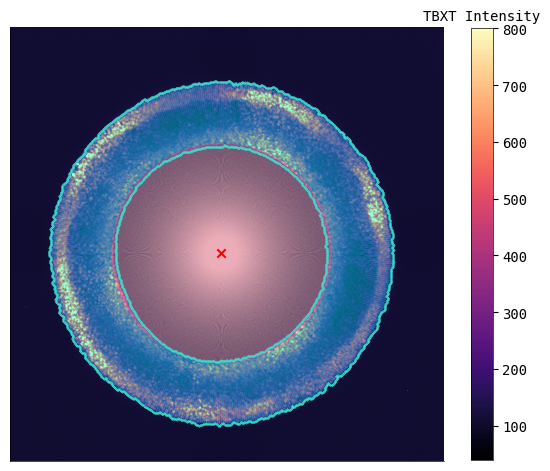

In [9]:
# to visualise
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(TBXT_channel, origin="lower", vmin=40, vmax=800, cmap="magma")
for i in range(len(angles)):
    coordinates = geo.obtain_row_col_idx(radii, angles[i], 0, centre)
    color = ["cyan" if i>=first_no_zero_column else "pink" for i in range(radii_res)] 
    # colour the lines depending on in micropatttern or not
    # boolean = geo.are_points_in_micropattern(large_contour, small_contour, coordinates)
    # color = ["turquoise" if value else "pink" for value in boolean]
    ax.scatter(coordinates[:,1], coordinates[:,0], alpha=0.05, color=color, s=0.6)
ax.scatter(centre[1], centre[0], marker='x', color='red')
ax.scatter(small_contour[:,1], small_contour[:,0], color="turquoise", s=0.1)
ax.scatter(large_contour[:,1], large_contour[:,0], color="turquoise", s=0.1)
ax.set_xlim(0, np.shape(DAPI_channel)[0])
ax.set_ylim(0, np.shape(DAPI_channel)[1])
ax.set_xticks([])
ax.set_yticks([])
# ax[0].set_title("TBXT channel")
clb = fig.colorbar(im, shrink=0.8)
clb.ax.set_title('TBXT Intensity',fontsize=10)

In [10]:
# plot mean of TBXT
mean_tbxt = geo.mean_ignore_zeros(TBXT_intensity)
mean_tbxt = np.trim_zeros(mean_tbxt, 'f')

In [11]:
inner_to_outer = radii[:len(mean_tbxt)]
peaks = signal.find_peaks(mean_tbxt)[0]
print(peaks)
all_peak_width = signal.peak_widths(mean_tbxt, peaks, rel_height=1)[0]
print(all_peak_width)

[  3  25  28  33  74  84  87  90  92 110 122 159 165]
[  1.12527233   2.14091178  83.94530787   2.78129713   1.06464025
   1.09679821   1.46382979   6.69230769   1.40782123   5.02876823
   1.40271493   1.04663774 187.77237616]


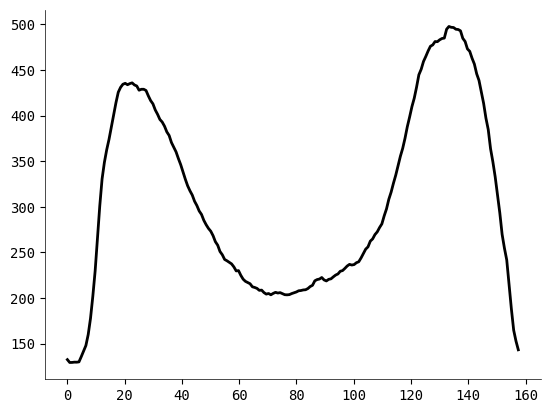

In [12]:
inner_to_outer = radii[:len(mean_tbxt)]
peaks = signal.find_peaks(mean_tbxt)[0]

fig, ax = plt.subplots()
ax.plot(inner_to_outer, mean_tbxt, color="black", linewidth=2)
# go through each peaks and jot down the widths
for i in range(len(peaks)):
    peak_width = signal.peak_widths(mean_tbxt, [peaks[i]], rel_height=0.8)
    fwhm = u.index_to_xdata(inner_to_outer, peak_width[0])

    # plot
    # ax.scatter(inner_to_outer[peaks[i]], mean_tbxt[peaks[i]], marker="x", label=f"{np.round(mean_tbxt[peaks[i]])}")
    # ax.hlines(*(peak_width[1], u.index_to_xdata(inner_to_outer, peak_width[2]), u.index_to_xdata(inner_to_outer, peak_width[3])))

# ax.legend()
# ax.axhline(y=250)

In [13]:
def first_crossing_index(y, value):
    """
    Return the first index where the array y crosses the specified value.
    The crossing is defined as a sign change in (y - value).
    Returns None if no crossing is found.
    """
    y = np.asarray(y)
    diff = np.sign(y - value)
    crossings = np.where(np.diff(diff) != 0)[0]
    return crossings if crossings.size > 0 else None

In [14]:
indices = first_crossing_index(mean_tbxt, 250)
print(indices)
widths_pixel = np.array([indices[1] - indices[0], indices[3] - indices[2]])
widths = widths_pixel * dx
print(widths)

[ 12  66 128 189]
[66.2472 74.8348]


In [15]:
# show peaks values
print(np.sort(mean_tbxt[peaks])[::-1])

[497.75       481.222      435.922      435.42       428.906
 236.916      230.084      222.528      208.694      206.254
 205.944      204.988      129.72727273]


In [16]:
# show peaks widths (in pixels)
print(np.sort(all_peak_width)[::-1] * dx)

[230.35915108 102.98410369   8.21012308   6.16929287   3.41209532
   2.62647057   1.79582638   1.72711508   1.72085068   1.3804841
   1.34555205   1.30610065   1.28401518]


In [17]:
### manually recorded data into file "../tbxt_width_dataframes/annulus_tbxt_data.xlsx"

In [18]:
# plot values
file_path = "../tbxt_width_dataframes/annulus_tbxt_data.xlsx"
df = pd.read_excel(file_path)
df.head()

,image_name,inner_peak,outer_peak,inner_width,outer_width,Unnamed: 5,notes
0,Maxproj_Process_20240212_JC001_annulusr1.5_48h...,425.0,484.0,77.2884,76.0616,NaN,NaN
1,Maxproj_Process_20240212_JC001_annulusr1.5_48h...,435.0,496.5,66.2472,74.8348,NaN,NaN
2,Maxproj_Process_20240212_JC001_annulusr1.5_48h...,440.0,440.0,67.4740,78.5152,NaN,NaN
3,Maxproj_Process_20240213_JC001_annulusr1.5_48h...,NaN,NaN,53.9792,76.0616,NaN,different range
4,Maxproj_Process_20240212_JC001_annulusr1.5_48h...,400.0,500.0,95.6904,87.1028,NaN,NaN


In [19]:
# copy data
inner_peak_1000 = np.array([425, 435, 440])
inner_peak_800 = np.array([400, 435, 426, 386])
outer_peak_1000 = np.array([484, 496.5, 440])
outer_peak_800 = np.array([500, 478, 455, 478])
widths = np.array([77.2884, 66.2472, 67.474, 53.9792, 95.6904, 66.2472, 77.2884, 98.144, 76.0616, 74.8348, 78.5152, 87.1028, 92.01, 94.4636, 94.4636])

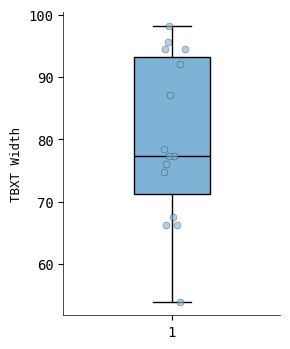

In [20]:
box_edge_color = 'black'
fill_color = '#7FB3D5'  # Use the first color
jitter_strength = 0.04
label = 'Inner Peak'  # Update accordingly
tick_label = 'Edge'   # X-axis label for the one position

# Example data (replace with your actual data)
data = widths  # or outers

plt.figure(figsize=(3, 3.6))

xpos = 1  # Single position for the plot

# Jittered scatter points
plt.scatter(np.random.normal(xpos, jitter_strength, size=len(data)), data,
            alpha=0.6, color=fill_color, edgecolor='black',
            linewidth=0.3, s=25, zorder=3)

# Boxplot
bp = plt.boxplot(data, positions=[xpos], widths=0.35, patch_artist=True, zorder=2)

# Styling the box
for patch in bp['boxes']:
    patch.set_facecolor(fill_color)
    patch.set_edgecolor(box_edge_color)

for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set_color(box_edge_color)

# Axis setup
# plt.xticks([xpos], [tick_label])
plt.ylabel("TBXT Width")

# Legend
legend_patch = Patch(facecolor=fill_color, edgecolor='black', label=label)

plt.tight_layout()
plt.show()

In [21]:
inners = np.concatenate([inner_peak_1000, inner_peak_800])
outers = np.concatenate([outer_peak_1000, outer_peak_800])

Text(0, 0.5, 'TBXT Intensity')

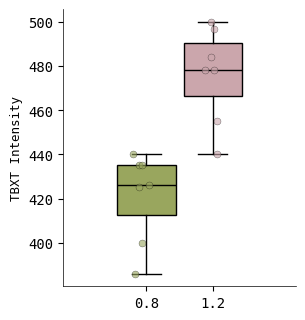

In [22]:
positions = [1, 2]
ticks = ['Edge', 'Corner']
data = [[inners, outers]]
labels = ['Inner Peak', 'Outer Peak']

plt.figure(figsize=(3, 3.6))

box_edge_color = 'black'  
fill_colors = ['#99A65E', '#CBA6AC']  # thanks chatgpt for the hexcodes
jitter_strength = 0.04

for i, (edge, squareedge) in enumerate(data):
    xpos1 = positions[i] - 0.2
    xpos2 = positions[i] + 0.2
            # Add jittered data points
    plt.scatter(np.random.normal(xpos1, jitter_strength, size=len(edge)), edge,
            alpha=0.6, color=fill_colors[0], edgecolor='black', linewidth=0.3, s=25, zorder=3)

    plt.scatter(np.random.normal(xpos2, jitter_strength, size=len(squareedge)), squareedge,
             alpha=0.6, color=fill_colors[1], edgecolor='black', linewidth=0.3, s=25, zorder=3)

    bp1 = plt.boxplot(edge, positions=[xpos1], widths=0.35, patch_artist=True, zorder=2)
    bp2 = plt.boxplot(squareedge, positions=[xpos2], widths=0.35, patch_artist=True, zorder=2)

    # colors n stuff
    for patch in bp1['boxes']:
        patch.set_facecolor(fill_colors[0])
        patch.set_edgecolor(box_edge_color)
    for patch in bp2['boxes']:
        patch.set_facecolor(fill_colors[1])
        patch.set_edgecolor(box_edge_color)

    for element in ['whiskers', 'caps', 'medians']:
        for line in bp1[element]:
            line.set_color(box_edge_color)
        for line in bp2[element]:
            line.set_color(box_edge_color)


legend_patches = [
    Patch(facecolor=fill_colors[0], edgecolor='black', label=labels[0]),
    Patch(facecolor=fill_colors[1], edgecolor='black', label=labels[1])
]

plt.ylabel("TBXT Intensity")
# plt.legend(handles=legend_patches, loc='best')

### Perform t-test for tbxt intensity

In [24]:
from scipy.stats import ttest_ind

In [27]:
t_stat, p_value = ttest_ind(inners, outers, equal_var=False)  # Welch's t-test is safer if variances differ
print(t_stat)
print(p_value)
print(f"T = {t_stat:.2f}, p = {p_value:.3f}")

-4.905857440116077
0.000366905835032725
T = -4.91, p = 0.000


In [29]:
if p_value < 0.001:
    sig = '***'
elif p_value < 0.01:
    sig = '**'
elif p_value < 0.05:
    sig = '*'
else:
    sig = 'ns'  # Not significant

print(sig)

***
